In [1]:
import os
import time
import random
import warnings
from datetime import date

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
# os.chdir(r'C:\Users\adamp\Projects\CVUT_BAP')
SEED=42
PRINT = True

# Načtení dat

In [2]:
df = pl.read_parquet(r'kod\data\extracted\prohlidky_vozidel_stk_a_sme\parquet', schema=prohlidky_schema)
if PRINT: describe(df)

CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,Prohlidka_Ukonceni,AdministrativniOprava_CisloProtokolu,AdministrativniOprava_DatumProhlidky,Vozidlo_Vin,Vozidlo_Druh,Vozidlo_Kategorie,Vozidlo_Provedeni,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Registrace_DatumPrvni,Registrace_Stat,Registrace_CisloDokladu,Emise_CisloProtokolu,Emise_DatumProhlidky,Emise_StaniceCislo,Emise_Zahajeni,Emise_Ukonceni,Emise_OdpovednaOsoba,Emise_ZakladniPalivo,Emise_AlternativniPalivo,Emise_EmisniSystem,Emise_VyrobceMotoru,Emise_CisloMotoru,Vysledek_Odometr,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[str],list[str],list[str]
"""CZ-520406-19-01-0001""","""2019-01-01""","""Pravidelná""",null,"""16835""","""520406""","""Středočeský kraj""","""Kolín""","""Žabonosy""","""2019-01-01T15:21:49.0770000+01…","""2019-01-01T15:40:05.4700000+01…",null,null,"""WV1ZZZ7HZ7H079425""","""NÁKLADNÍ AUTOMOBIL""","""N1""",null,"""VW""","""TRANSPORTER""","""BPC""","""2007-01-03T00:00:00.0000000+01…","""Česká republika""","""UB654181""","""CZ-520406-19-01-0001""","""2019-01-01T15:40:05.4700000+01…","""520406""","""2019-01-01T15:22:33.2900000+01…","""2019-01-01T15:39:51.5500000+01…","""16835""","""Nafta""",null,"""Řízený s OBD""",null,null,"""309068""",null,"""2021-01-01""",null,"""1""","""False""","""False""","""False""",null,null,null


(20547046, 45)


,CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,...,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C
0,CZ-520406-19-01-0001,2019-01-01,Pravidelná,None,16835,520406,Středočeský kraj,Kolín,Žabonosy,2019-01-01T15:21:49.0770000+01:00,...,None,2021-01-01,None,1,False,False,False,NaN,NaN,NaN
1,CZ-420930-19-01-0001,2019-01-01,Pravidelná,None,43281,420930,Středočeský kraj,Říčany,Říčany,2019-01-01T14:35:04.4400000+01:00,...,None,2021-01-01,None,1,False,False,False,NaN,NaN,NaN
2,CZ-480811-23-01-0001,2023-01-01,Pravidelná,None,36479,480811,Olomoucký kraj,Přerov,Kojetín,2023-01-01T12:21:49.8570000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
3,CZ-420221-23-01-0004,2023-01-01,Pravidelná,None,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01T17:25:41.6570000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
4,CZ-420221-23-01-0001,2023-01-01,Pravidelná,None,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01T16:05:05.4600000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
5,CZ-420221-23-01-0003,2023-01-01,Pravidelná,None,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01T16:56:47.6530000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
6,CZ-170901-23-01-0001,2023-01-01,Pravidelná,None,89493,170901,Olomoucký kraj,Prostějov,Bedihošť,2023-01-01T19:23:52.2530000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
7,CZ-170901-23-01-0002,2023-01-01,Pravidelná,None,89493,170901,Olomoucký kraj,Prostějov,Bedihošť,2023-01-01T19:40:36.1970000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
8,CZ-520406-24-01-0001,2024-01-01,Pravidelná,None,1308,520406,Středočeský kraj,Kolín,Žabonosy,2024-01-01T11:30:09.4530000+01:00,...,None,2026-01-01,None,1,False,False,False,NaN,NaN,NaN
9,CZ-480811-24-01-0001,2024-01-01,Pravidelná,None,36479,480811,Olomoucký kraj,Přerov,Kojetín,2024-01-01T16:21:48.9530000+01:00,...,None,2026-01-01,None,1,False,False,False,NaN,NaN,NaN


,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-410446-21-10-0285,2 / 20 547 046,0 / 20 547 046,String
1,DatumProhlidky,2025-05-12,18 312 / 20 547 046,0 / 20 547 046,String
2,DruhProhlidky,Pravidelná,20 481 884 / 20 547 046,0 / 20 547 046,String
3,RozsahProhlidky,Plný,983 077 / 20 547 046,19 546 141 / 20 547 046,String
4,Prohlidka_OdpovednaOsoba,35165,70 087 / 20 547 046,0 / 20 547 046,String
5,Prohlidka_Stanice_Cislo,540514,354 696 / 20 547 046,0 / 20 547 046,String
6,Prohlidka_Stanice_Kraj,Středočeský kraj,3 022 616 / 20 547 046,0 / 20 547 046,String
7,Prohlidka_Stanice_ORP,Hlavní město Praha,2 058 735 / 20 547 046,0 / 20 547 046,String
8,Prohlidka_Stanice_Obec,Praha,2 058 735 / 20 547 046,0 / 20 547 046,String
9,Prohlidka_Zahajeni,2022-03-17T00:00:00.0000000+01:00,25 / 20 547 046,0 / 20 547 046,String


# Filtrace vozidel kategorie M1 s palivem Benzín / Nafta

In [3]:
if PRINT:
    display(df['Vozidlo_Kategorie'].value_counts(sort=True))
    display(df['Emise_ZakladniPalivo'].value_counts(sort=True))
    display(df['Emise_AlternativniPalivo'].value_counts(sort=True))

Vozidlo_Kategorie,count
str,u32
"""M1""",16767348
"""N1""",1634724
"""N3""",625762
"""M1G""",514192
"""N2""",337768
…,…
"""L1e-A""",1
"""L7e-B1""",1
"""L6e""",1


Emise_ZakladniPalivo,count
str,u32
"""Nafta""",10808838
"""Benzín""",9633026
"""CNG""",67778
"""Směs""",36693
"""LNG""",441
"""LPG""",270


Emise_AlternativniPalivo,count
str,u32
null,20080548
"""LPG""",432510
"""CNG""",33840
"""LNG""",148


In [4]:
df = df.filter(pl.col('Vozidlo_Kategorie') == 'M1', pl.col('Emise_ZakladniPalivo').is_in(['Benzín', 'Nafta']), pl.col('Emise_AlternativniPalivo').is_null())
if PRINT: schema_description(df)

,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-130102-21-10-0185,2 / 16 283 100,0 / 16 283 100,String
1,DatumProhlidky,2025-05-12,14 774 / 16 283 100,0 / 16 283 100,String
2,DruhProhlidky,Pravidelná,16 231 312 / 16 283 100,0 / 16 283 100,String
3,RozsahProhlidky,Plný,759 696 / 16 283 100,15 510 198 / 16 283 100,String
4,Prohlidka_OdpovednaOsoba,35165,55 884 / 16 283 100,0 / 16 283 100,String
5,Prohlidka_Stanice_Cislo,540514,256 222 / 16 283 100,0 / 16 283 100,String
6,Prohlidka_Stanice_Kraj,Středočeský kraj,2 352 590 / 16 283 100,0 / 16 283 100,String
7,Prohlidka_Stanice_ORP,Hlavní město Praha,1 690 770 / 16 283 100,0 / 16 283 100,String
8,Prohlidka_Stanice_Obec,Praha,1 690 770 / 16 283 100,0 / 16 283 100,String
9,Prohlidka_Zahajeni,2025-11-03T08:37:33.2830000+01:00,7 / 16 283 100,0 / 16 283 100,String


# Přetypování sloupců
Velke mnozstvi zaznamu ma odlisne cislo protokolu pouze z duvodu predchazejicich nul

In [5]:
if PRINT:
    print('Záznamy, kde neodpovídá CisloProtokolu a Emise_CisloProtokolu')
    short_display(df[['CisloProtokolu', 'Emise_CisloProtokolu']].filter(pl.col('CisloProtokolu') != pl.col('Emise_CisloProtokolu')))
df = cast_prohlidka(df)

Záznamy, kde neodpovídá CisloProtokolu a Emise_CisloProtokolu
(772902, 2)


,CisloProtokolu,Emise_CisloProtokolu
0,CZ-3848-19-02-0017,CZ-003848-19-02-0017
1,CZ-3848-19-02-0012,CZ-003848-19-02-0012
2,CZ-3848-19-02-0003,CZ-003848-19-02-0003
3,CZ-3848-19-02-0010,CZ-003848-19-02-0010
4,CZ-3848-19-02-0014,CZ-003848-19-02-0014
5,CZ-3848-19-02-0011,CZ-003848-19-02-0011
6,CZ-3848-19-02-0006,CZ-003848-19-02-0006
7,CZ-3848-19-02-0002,CZ-003848-19-02-0002
8,CZ-3618-21-02-0101,CZ-003618-21-02-0101
9,CZ-3706-21-02-0051,CZ-003706-21-02-0051


# Odstranění nekonzistentních CiselProtokolu
Pouze 3 cisla protokolu nejsou stejna

In [6]:
inconsistent_cislo_protokolu = df[['CisloProtokolu', 'Emise_CisloProtokolu']].filter(pl.col('CisloProtokolu') != pl.col('Emise_CisloProtokolu'))['CisloProtokolu'].to_list()
if PRINT: print(inconsistent_cislo_protokolu)
df = df.filter(~pl.col('CisloProtokolu').is_in(inconsistent_cislo_protokolu))

['CZ-3420-24-02-0512', 'CZ-3420-24-02-0563', 'CZ-3420-24-02-0561']


# Odstranění duplicitních čísel protokolu
Nektere zaznamy se v datove sade vyskytuji vicektrat

In [7]:
if PRINT: short_display(df.filter(pl.col('CisloProtokolu').count().over('CisloProtokolu') > 1).sort('CisloProtokolu'))
df = df.unique()
if PRINT: short_display(df.filter(pl.col('CisloProtokolu').count().over('CisloProtokolu') > 1).sort('CisloProtokolu'))

(1340, 45)


,CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,...,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C
0,CZ-110301-25-03-0153,2025-03-26,Pravidelná,None,101929,110301,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:29.103,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
1,CZ-110301-25-03-0153,2025-03-26,Pravidelná,None,101929,110301,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:29.103,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
2,CZ-110503-25-03-0726,2025-03-26,Pravidelná,None,82867,110503,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 14:03:43.330,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
3,CZ-110503-25-03-0726,2025-03-26,Pravidelná,None,82867,110503,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 14:03:43.330,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
4,CZ-110802-25-03-0421,2025-03-26,Pravidelná,None,112949,110802,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:44.957,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
5,CZ-110802-25-03-0421,2025-03-26,Pravidelná,None,112949,110802,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:44.957,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
6,CZ-110901-21-10-0224,2021-10-12,Pravidelná,None,55017,110901,Hlavní město Praha,Hlavní město Praha,Praha,2021-10-12 07:57:03.890,...,None,2023-10-12,None,1,False,False,False,NaN,NaN,NaN
7,CZ-110901-21-10-0224,2021-10-12,Pravidelná,None,55017,110901,Hlavní město Praha,Hlavní město Praha,Praha,2021-10-12 07:57:03.890,...,None,2023-10-12,None,1,False,False,False,NaN,NaN,NaN
8,CZ-110905-25-03-0145,2025-03-26,Pravidelná,None,912,110905,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:59:10.907,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
9,CZ-110905-25-03-0145,2025-03-26,Pravidelná,None,912,110905,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:59:10.907,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN


(0, 45)


,CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,...,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C


# Zapracování administrativních oprav
## Charakteristiky administrativnich oprav
- Nektere protokoly se jsou opravovany vicekrat
- Nektere administrativni opravy se odkazuji na protokoly, ktere v datove sade nejsou

In [8]:
df_repairs = df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())
if PRINT: print(f'Pocet administrativnich oprav: {len(df_repairs)}')

if PRINT: print('Pocty oprav alespon jednou opravovanych protokolu:')
if PRINT: display(df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())['AdministrativniOprava_CisloProtokolu'].value_counts().group_by(by='count').len().sort(by='by'))

df_repairs_of_repairs = df.filter(pl.col("AdministrativniOprava_CisloProtokolu").is_in(df.filter(pl.col("AdministrativniOprava_CisloProtokolu").is_not_null())["CisloProtokolu"].to_list()))
if PRINT: print(f'Pocet oprav opravujicich opravy: {len(df_repairs_of_repairs)}')


Pocet administrativnich oprav: 63781
Pocty oprav alespon jednou opravovanych protokolu:


by,len
u32,u32
1,63381
2,194
3,4


Pocet oprav opravujicich opravy: 1728


### Prevedeni odkazu administrativni opravy na korenovy zaznam

In [9]:
parent_map = dict(zip(df["CisloProtokolu"], df["AdministrativniOprava_CisloProtokolu"]))

def get_absolute_root(protocol_id):
    current = protocol_id
    visited = set()
    while parent_map.get(current) is not None:
        if current in visited:
            raise ValueError("Cyklicka reference")
        visited.add(current)
        current = parent_map.get(current)
    return current

df = df.with_columns(
    pl.col("CisloProtokolu").map_elements(get_absolute_root, return_dtype=pl.Utf8).alias("Absolutni_Koren")
).with_columns(
    pl.when(pl.col("CisloProtokolu") != pl.col("Absolutni_Koren"))
    .then(pl.col("Absolutni_Koren"))
    .otherwise(pl.lit(None))
    .alias("AdministrativniOprava_CisloProtokolu")
).drop("Absolutni_Koren")

### Odstraneni sirotcich oprav

In [10]:
df_orphaned_repairs = df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null()).join(df.select('CisloProtokolu'), left_on='AdministrativniOprava_CisloProtokolu', right_on='CisloProtokolu', how='anti')
if PRINT: print(f'Pocet administrativnich oprav, ktere se odkazuji na neexistujici protokol: {len(df_orphaned_repairs)}')
df = df.join(df_orphaned_repairs.select("CisloProtokolu"), on="CisloProtokolu", how="anti")

Pocet administrativnich oprav, ktere se odkazuji na neexistujici protokol: 757


### Situace po sjednoceni oprav

In [11]:
df_repairs = df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())
if PRINT: print(f'Pocet administrativnich oprav: {len(df_repairs)}')

if PRINT: print('Pocty oprav alespon jednou opravovanych protokolu:')
if PRINT: display(df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())['AdministrativniOprava_CisloProtokolu'].value_counts().group_by(by='count').len().sort(by='by'))

df_repairs_of_repairs = df.filter(pl.col("AdministrativniOprava_CisloProtokolu").is_in(df.filter(pl.col("AdministrativniOprava_CisloProtokolu").is_not_null())["CisloProtokolu"].to_list()))
if PRINT: print(f'Pocet oprav opravujicich opravy: {len(df_repairs_of_repairs)}')

df_orphaned_repairs = df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null()).join(df.select('CisloProtokolu'), left_on='AdministrativniOprava_CisloProtokolu', right_on='CisloProtokolu', how='anti')
if PRINT: print(f'Pocet administrativnich oprav, ktere se odkazuji na neexistujici protokol: {len(df_orphaned_repairs)}')

Pocet administrativnich oprav: 63024
Pocty oprav alespon jednou opravovanych protokolu:


by,len
u32,u32
1,59314
2,1731
3,76
4,5


Pocet oprav opravujicich opravy: 0
Pocet administrativnich oprav, ktere se odkazuji na neexistujici protokol: 0


## Identifikace změn
Je potreba pocitat s tim, ze nekktere protokoly byly meneny vicekrat

In [12]:
# Definice ignorovanych
ignore_cols = {
    'DatumProhlidky',
    'Prohlidka_Zahajeni', 
    'Prohlidka_Ukonceni', 
    'AdministrativniOprava_CisloProtokolu', 
    'AdministrativniOprava_DatumProhlidky',
    'CisloProtokolu',
    'Emise_CisloProtokolu',
    'Emise_DatumProhlidky',
    'Emise_Zahajeni',
    'Emise_Ukonceni',
    'Vysledek_Poznamka',
}
    
if PRINT:
    # Dynamické určení sledovaných sloupců
    compare_cols = [c for c in df.columns if c not in ignore_cols]

    def to_str_expr(col_name):
        dtype = df.schema[col_name]
        if isinstance(dtype, pl.List):
            return pl.col(col_name).list.join(", ").cast(pl.Utf8)
        return pl.col(col_name).cast(pl.Utf8)

    # Finální optimalizovaný proces
    final_diff_table = (
        df.lazy()
        .with_columns(
            pl.coalesce("AdministrativniOprava_CisloProtokolu", "CisloProtokolu").alias("Family_ID")
        )
        .sort("Prohlidka_Ukonceni")
        .select([
            pl.col("CisloProtokolu").alias("Protokol_Opravy"),
            pl.col("Family_ID").alias("Opravovany_Protokol"),
            *[
                pl.when(
                    (pl.col(c) != pl.col(c).shift().over("Family_ID")) |
                    (pl.col(c).is_null() != pl.col(c).shift().over("Family_ID").is_null())
                )
                .then(
                    pl.struct(
                        Zmeneny_Parametr=pl.lit(c),
                        Puvodni_Hodnota=to_str_expr(c).shift().over("Family_ID"),
                        Nova_Hodnota=to_str_expr(c)
                    )
                )
                .otherwise(None)
                .alias(c)
                for c in compare_cols
            ]
        ])
        # Odstranění řádků, které nejsou opravami (kořenové protokoly)
        .filter(pl.col("Protokol_Opravy") != pl.col("Opravovany_Protokol"))
        .unpivot(
            index=["Protokol_Opravy", "Opravovany_Protokol"],
            on=compare_cols,
            value_name="Changes"
        )
        .filter(pl.col("Changes").is_not_null())
        .unnest("Changes")
        .drop("variable") # unpivot automaticky vytváří 'variable', zde duplicitní k Zmeneny_Parametr
        .sort(["Opravovany_Protokol", "Protokol_Opravy"])
        .collect()
    )

In [13]:
if PRINT: print(f'Prumerny pocet menenych parametru: {len(final_diff_table)/len(df_repairs)}')

Prumerny pocet menenych parametru: 1.0249428789032748


## Vykreslení nejčastěji měněných parametru

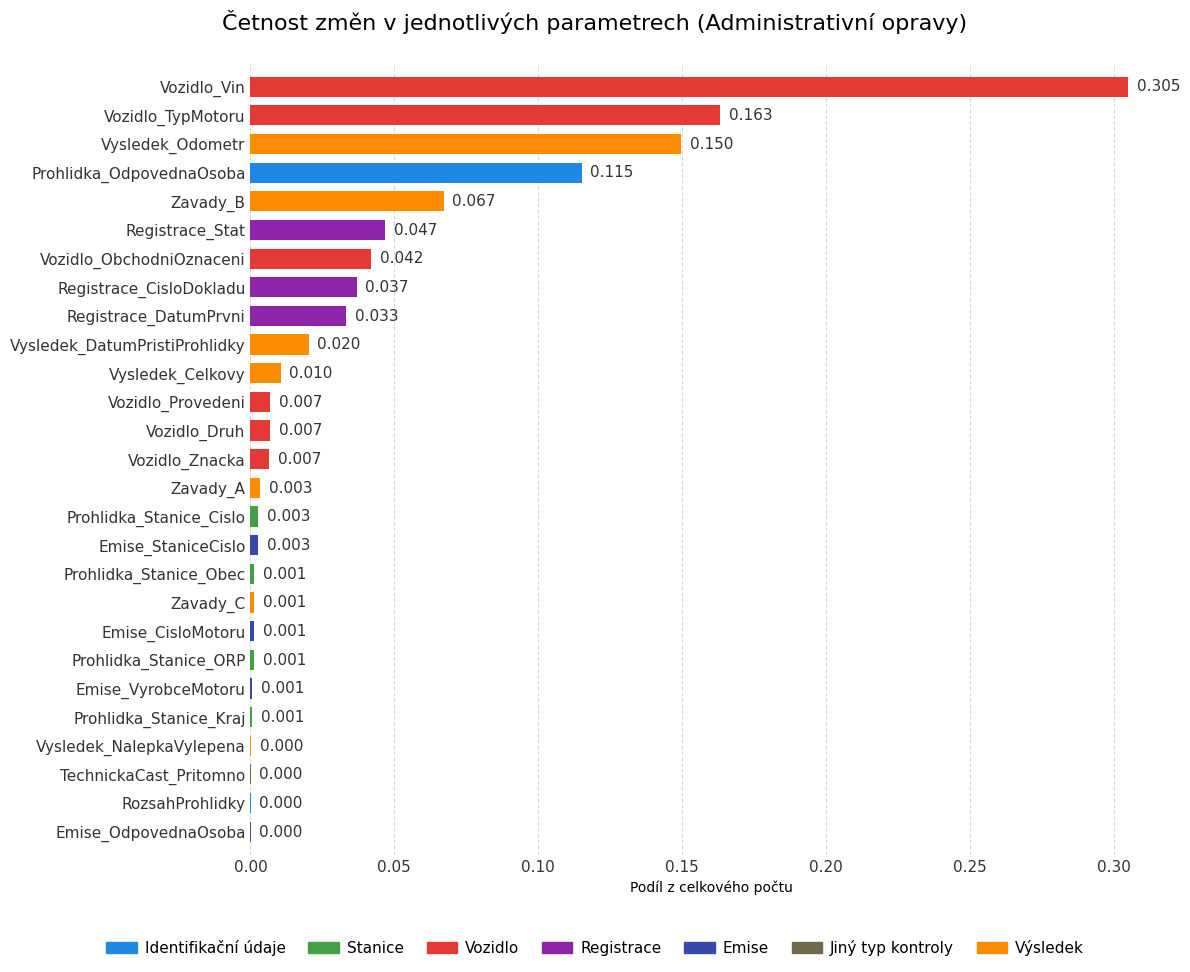

In [14]:
if PRINT:
    # Agregace počtu změn na parametr
    summary = final_diff_table.group_by('Zmeneny_Parametr').len().sort('len', descending=True)

    columns = summary['Zmeneny_Parametr'].to_list()
    counts = summary['len'].to_list()
    total_revisions = df_repairs.height
    ratios = [c / total_revisions if total_revisions > 0 else 0 for c in counts]

    group_indices = [prohlidky_group_mapping[col] for col in columns]
    group_descriptions = ['Identifikační údaje', 'Stanice', 'Časové údaje', 'Vozidlo', 'Registrace', 'Emise', 'Jiný typ kontroly', 'Výsledek', 'Administrativní oprava']
    horizontal_bar(columns, ratios, 'Četnost změn v jednotlivých parametrech (Administrativní opravy)', "kod/explorace/prohlidky_grafy/prohlidky_administrativni_opravy.svg", 3, 10, group_indices, group_descriptions)

## Zanesení administrativních oprav
Nasledujici kod funguje diky uprave na korenovy protokol

In [15]:
# Sloupce určené k přepsání daty z oprav
update_cols = [c for c in df.columns if c not in ignore_cols]

# Získání posledních verzí oprav pro každý protokol
latest_corrections = (
    df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())
    .sort('Prohlidka_Ukonceni')
    .group_by('AdministrativniOprava_CisloProtokolu', maintain_order=True)
    .last()
    .with_columns(pl.lit(True).alias('_has_correction'))
)

# Aplikace oprav na originální záznamy
df = (
    df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_null())
    .join(
        latest_corrections.select(
            ['AdministrativniOprava_CisloProtokolu', '_has_correction'] + 
            [pl.col(c).alias(f"{c}_Latest") for c in update_cols]
        ),
        left_on='CisloProtokolu',
        right_on='AdministrativniOprava_CisloProtokolu',
        how='left'
    )
    .with_columns([
        # Nahrazení hodnotou z opravy, pokud existuje (včetně null hodnot)
        *[
            pl.when(pl.col('_has_correction').fill_null(False))
            .then(pl.col(f"{c}_Latest"))
            .otherwise(pl.col(c))
            .alias(c)
            for c in update_cols
        ],
        # Informace o tom, zda byl zaznam opravovan
        pl.col('_has_correction').fill_null(False).alias('AdministrativneOpraveno'),
    ])
    .select([*df.columns, "AdministrativneOpraveno"]) # Vezme vše původní + nový bool
    .select(pl.exclude(['AdministrativniOprava_CisloProtokolu', 'AdministrativniOprava_DatumProhlidky']))
)

# Odstranění vybraných sloupců
- nerelevantních sloupců
- sloupců přítomných v jiných datových sadách s vyšší kvalitou
- sloupcu pritomnych je u techncikych prohlidek


In [16]:
irrelevant_columns = ['Registrace_CisloDokladu', 'Vozidlo_Vin', 'Vozidlo_Kategorie', 'Emise_CisloProtokolu', 'Emise_AlternativniPalivo', 'Emise_VyrobceMotoru', 'Emise_DatumProhlidky', 'Emise_CisloMotoru', 'Vysledek_Poznamka', 'Vysledek_DatumPristiProhlidky', 'Vysledek_Celkovy', 'Zavady_A', 'Zavady_B', 'Zavady_C']
duplicate_columns = ['Emise_EmisniSystem']
df = df.drop(irrelevant_columns + duplicate_columns)

In [17]:
if PRINT:
    print(f'Pocet zanamu obsahujicich RozsahProhlidky bez TechnickeCasti_Pritomno: {df.filter(pl.col('RozsahProhlidky').is_not_null()).select((pl.col('TechnickaCast_Pritomno') == False).sum()).item()}.')
    print(f'Pocet zanamu obsahujicich Vysledek_NalepkaVylepena bez TechnickeCasti_Pritomno: {df.filter(pl.col('Vysledek_NalepkaVylepena').is_not_null()).select((pl.col('TechnickaCast_Pritomno') == False).sum()).item()}.')

df = df.drop('RozsahProhlidky')
df = df.drop('Vysledek_NalepkaVylepena')

Pocet zanamu obsahujicich RozsahProhlidky bez TechnickeCasti_Pritomno: 0.
Pocet zanamu obsahujicich Vysledek_NalepkaVylepena bez TechnickeCasti_Pritomno: 0.


In [18]:
if PRINT: print(f'Pocet stanic, kde se nerovna cislo stanice prohlidky a emise: {df.filter(pl.col('Prohlidka_Stanice_Cislo') != pl.col('Emise_StaniceCislo')).height}')
df = df.drop('Emise_StaniceCislo')

Pocet stanic, kde se nerovna cislo stanice prohlidky a emise: 0


## Dataset po zanesení administrativních kontrol

In [19]:
df = df.select(['CisloProtokolu', 'DruhProhlidky', 'Prohlidka_OdpovednaOsoba', 'Prohlidka_Stanice_Cislo', 'Prohlidka_Stanice_Kraj', 'Prohlidka_Stanice_ORP', 'Prohlidka_Stanice_Obec', 'DatumProhlidky', 'Prohlidka_Zahajeni', 'Prohlidka_Ukonceni', 'Vozidlo_Druh', 'Vozidlo_Provedeni', 'Vozidlo_Znacka', 'Vozidlo_ObchodniOznaceni', 'Vozidlo_TypMotoru', 'Registrace_DatumPrvni', 'Registrace_Stat', 'Emise_OdpovednaOsoba', 'Emise_Zahajeni', 'Emise_Ukonceni', 'Emise_ZakladniPalivo', 'TechnickaCast_Pritomno', 'AdrCast_Pritomno', 'TskCast_Pritomno', 'Vysledek_Odometr', 'AdministrativneOpraveno'])
if PRINT: schema_description(df)
df.write_parquet(r"kod\data\processed\prohlidky_clean.parquet")

,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-480764-24-04-0465,1 / 16 218 646,0 / 16 218 646,String
1,DruhProhlidky,Pravidelná,16 166 860 / 16 218 646,0 / 16 218 646,String
2,Prohlidka_OdpovednaOsoba,35165,55 725 / 16 218 646,0 / 16 218 646,Int32
3,Prohlidka_Stanice_Cislo,540514,254 043 / 16 218 646,0 / 16 218 646,Int32
4,Prohlidka_Stanice_Kraj,Středočeský kraj,2 344 213 / 16 218 646,0 / 16 218 646,String
5,Prohlidka_Stanice_ORP,Hlavní město Praha,1 682 833 / 16 218 646,0 / 16 218 646,String
6,Prohlidka_Stanice_Obec,Praha,1 682 833 / 16 218 646,0 / 16 218 646,String
7,DatumProhlidky,2025-05-12,14 746 / 16 218 646,0 / 16 218 646,Date
8,Prohlidka_Zahajeni,2025-11-03 08:37:33.283000,7 / 16 218 646,0 / 16 218 646,"Datetime(time_unit='us', time_zone=None)"
9,Prohlidka_Ukonceni,2019-04-11 10:15:00,6 / 16 218 646,0 / 16 218 646,"Datetime(time_unit='us', time_zone=None)"


# Chybějící hodnoty

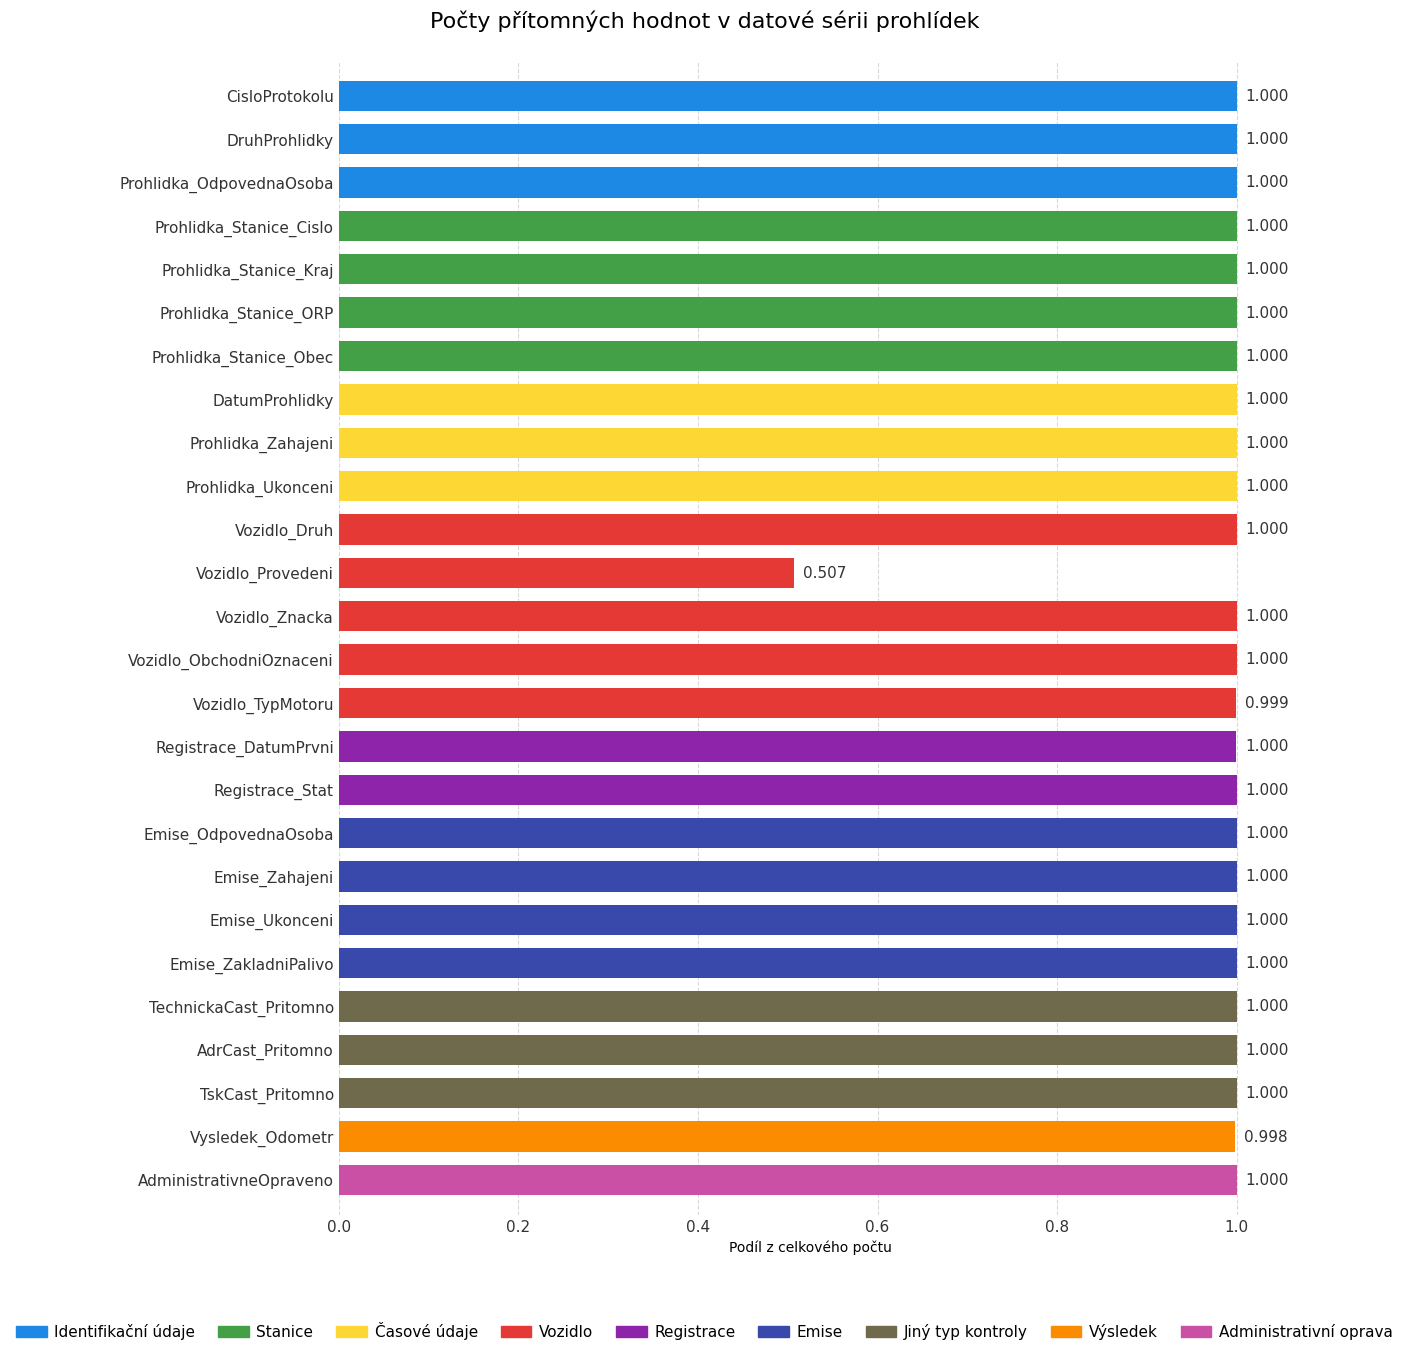

Pocet chybejicich hodnot u "Registrace_DatumPrvni": 4875


In [20]:
if PRINT:
    # Výpočet metrik
    total_rows = len(df)
    columns = df.columns
    null_counts = df.null_count().row(0)
    non_null_counts = [total_rows - count for count in null_counts]
    ratios = [count / total_rows if total_rows > 0 else 0 for count in non_null_counts]

    prohlidky_group_mapping['AdministrativneOpraveno'] = 8
    group_indices = [prohlidky_group_mapping[col] for col in columns]

    group_descriptions = ['Identifikační údaje', 'Stanice', 'Časové údaje', 'Vozidlo', 'Registrace', 'Emise', 'Jiný typ kontroly', 'Výsledek', 'Administrativní oprava']
    horizontal_bar(
        labels=columns, 
        counts=ratios, 
        title='Počty přítomných hodnot v datové sérii prohlídek', 
        save_path='kod/explorace/prohlidky_grafy/prohlidky_pritomne_hodnoty.svg', 
        decimals=3, 
        height=14, 
        group_indices=group_indices, 
        group_descriptions=group_descriptions
    )
    print(f'Pocet chybejicich hodnot u "Registrace_DatumPrvni": {df['Registrace_DatumPrvni'].null_count()}')

# Analýza jednotlivých příznaků
## Druh prohlídky
- Odstraneni tohoto sloupce

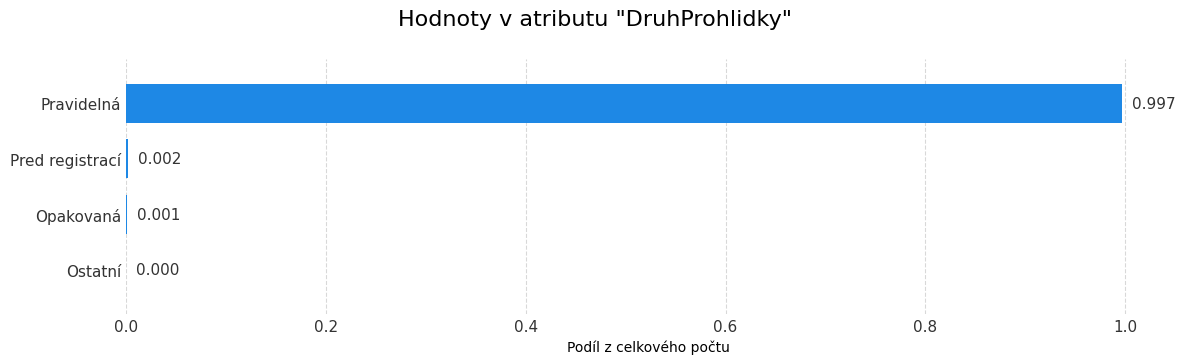

Podíl opakovaných prohlídek na všech 0.097 %


In [21]:
if PRINT:
    exam_types = df['DruhProhlidky'].value_counts().sort(by='count', descending=True)
    horizontal_bar(exam_types['DruhProhlidky'], exam_types['count'] / df.height, 'Hodnoty v atributu "DruhProhlidky"', 'kod/explorace/prohlidky_grafy/prohlidky_druh_prohlidky.svg', max_bars=4, height=4, decimals=3)
    print(f'Podíl opakovaných prohlídek na všech {exam_types.filter(pl.col('DruhProhlidky') == 'Opakovaná')['count'].item() / exam_types['count'].sum() * 100:.3} %')
df = df.drop('DruhProhlidky')

## Prohlidka, Emise odpovedna osoba

In [22]:
if PRINT:
    print(df['Prohlidka_OdpovednaOsoba'].n_unique())
    df.group_by("Prohlidka_OdpovednaOsoba").agg(pl.col("Prohlidka_Stanice_Cislo").n_unique().alias('PocetStanic')).filter(pl.col('PocetStanic') > 1).sort(by='PocetStanic', descending=True)

4176


In [23]:
if PRINT:
    print(f'Podil pripadu, kdy se odpovedna osoba v prohlidce a v emisisch neshoduje: {df.filter(pl.col('Prohlidka_OdpovednaOsoba') != pl.col('Emise_OdpovednaOsoba')).height / df.height *100:.2f} %')
    print(f'Podil pripadu, kdy se odpovedna osoba v prohlidce a v emisisch neshoduje (technicka pritomno): {df.filter(pl.col('TechnickaCast_Pritomno') == True).filter(pl.col('Prohlidka_OdpovednaOsoba') != pl.col('Emise_OdpovednaOsoba')).height / df.filter(pl.col('TechnickaCast_Pritomno') == True).height *100:.2f} %')

Podil pripadu, kdy se odpovedna osoba v prohlidce a v emisisch neshoduje: 20.70 %
Podil pripadu, kdy se odpovedna osoba v prohlidce a v emisisch neshoduje (technicka pritomno): 84.02 %


## Prohlidka, Emise stanice cislo

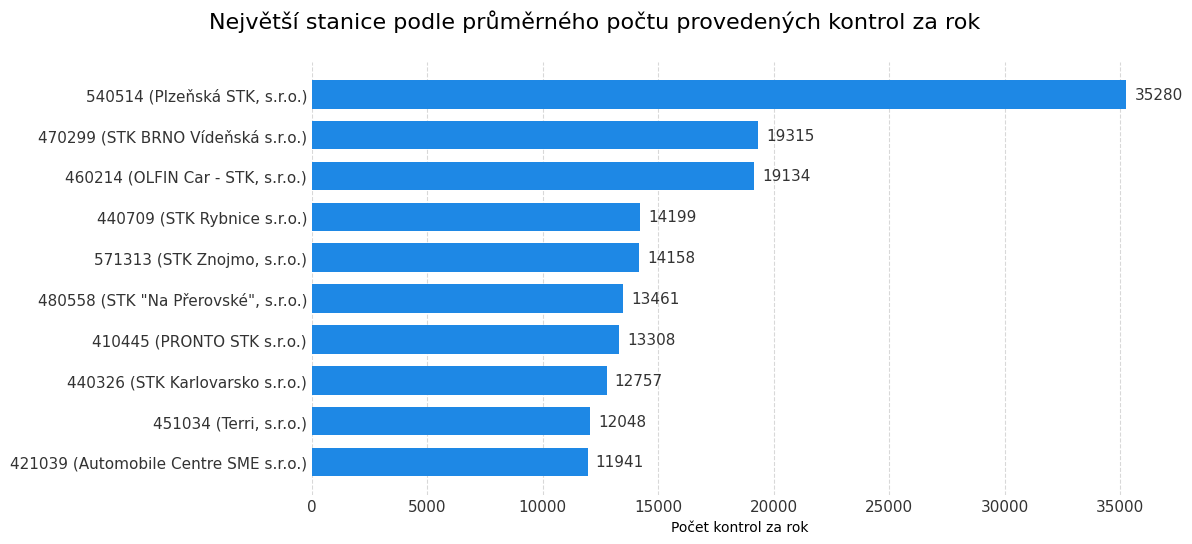

Podil prohlidek nejvetsi stanice na celku: 0.86 %


In [24]:
if PRINT:
    # Pomocne informace
    timeframe = df.select(diff_years = (pl.col("DatumProhlidky").max() - pl.col("DatumProhlidky").min()).dt.total_days() / 365.24).item()
    provozovatel_mapping = pl.read_parquet(r"kod\data\processed\stanice.parquet")

    # Samotne nalezeni top stanic
    top_stanice = df['Prohlidka_Stanice_Cislo'].value_counts().sort(by='count', descending=True).head(10)

    labels = top_stanice.select(pl.col('Prohlidka_Stanice_Cislo').cast(pl.String)).join(provozovatel_mapping, how='left', left_on='Prohlidka_Stanice_Cislo', right_on='Stanice_Cislo').select(merged = pl.col("Prohlidka_Stanice_Cislo") + " (" + pl.col("Provozovatel_Nazev") + ")")['merged'].to_list()
    counts = (top_stanice['count'] / timeframe).to_list()
    title = f'Největší stanice podle průměrného počtu provedených kontrol za rok'
    path = 'kod/explorace/prohlidky_grafy/prohlidky_top_stanice.svg'

    horizontal_bar(labels, counts, title, path, x_label='Počet kontrol za rok')
    print(f'Podil prohlidek nejvetsi stanice na celku: {top_stanice['count'].item(1) / df.height * 100:.2f} %')

## Prohlidka stanice kraj

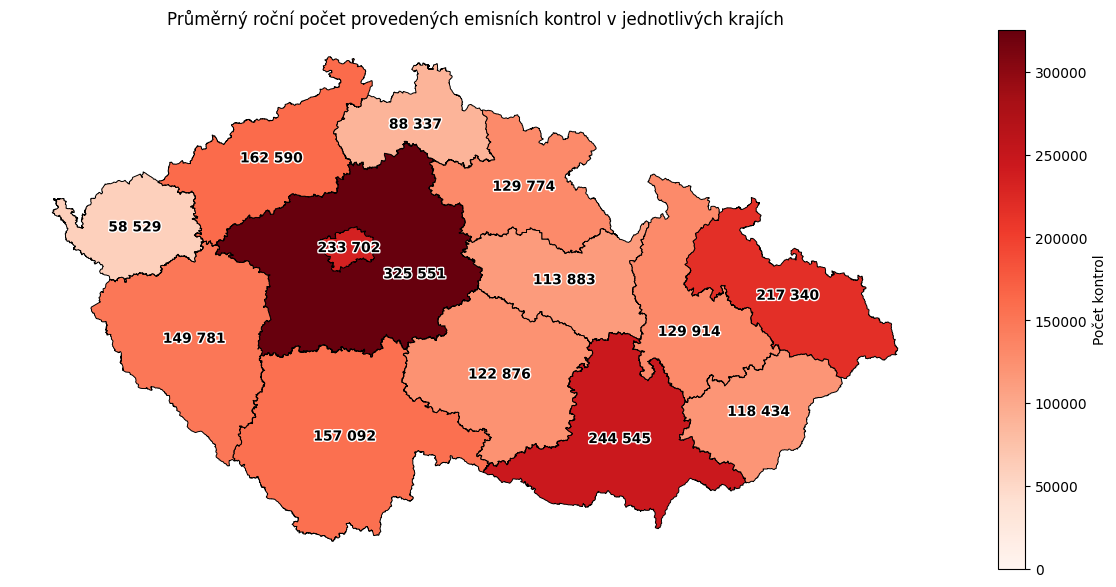

In [25]:
if PRINT:
    # Definice převodníku
    kraje_mapping = {
        "Hlavní město Praha": "CZ0100000000",
        "Středočeský kraj": "CZ0200000000",
        "Jihočeský kraj": "CZ0310000000",
        "Plzeňský kraj": "CZ0320000000",
        "Karlovarský kraj": "CZ0410000000",
        "Ústecký kraj": "CZ0420000000",
        "Liberecký kraj": "CZ0510000000",
        "Královéhradecký kraj": "CZ0520000000",
        "Pardubický kraj": "CZ0530000000",
        "Kraj Vysočina": "CZ0630000000",
        "Jihomoravský kraj": "CZ0640000000",
        "Olomoucký kraj": "CZ0710000000",
        "Zlínský kraj": "CZ0720000000",
        "Moravskoslezský kraj": "CZ0800000000"
    }

    # Agregace v Polars
    counts_pl = df.with_columns(pl.col("Prohlidka_Stanice_Kraj").replace(kraje_mapping).alias("kod_kraje")).group_by("kod_kraje").agg((pl.len() / timeframe).alias("pocet"))

    plot_czech_regional_map(counts_pl=counts_pl, value_column="pocet", title='Průměrný roční počet provedených emisních kontrol v jednotlivých krajích', legend_label="Počet kontrol", output_path="kod/explorace/prohlidky_grafy/prohlidky_pocty_mapa.svg")

## Datum prohlidky

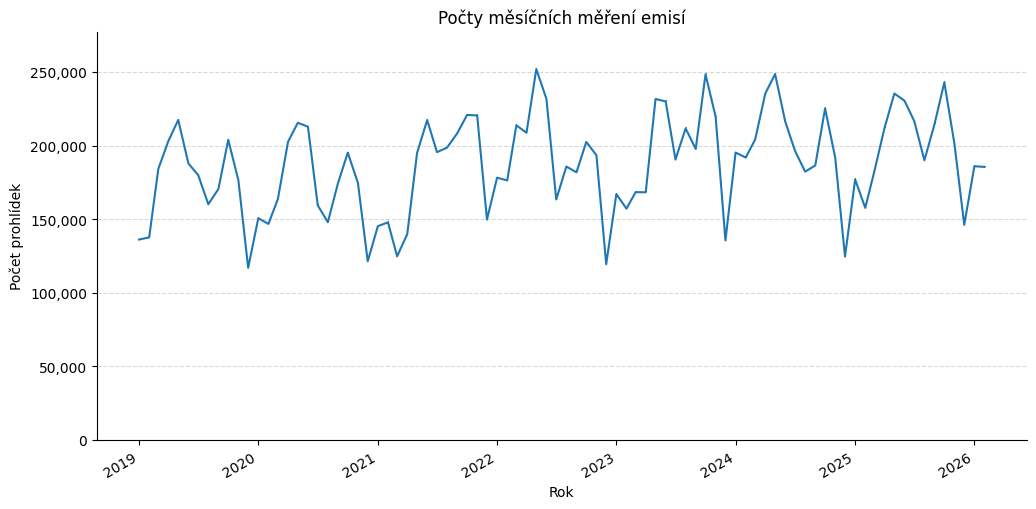

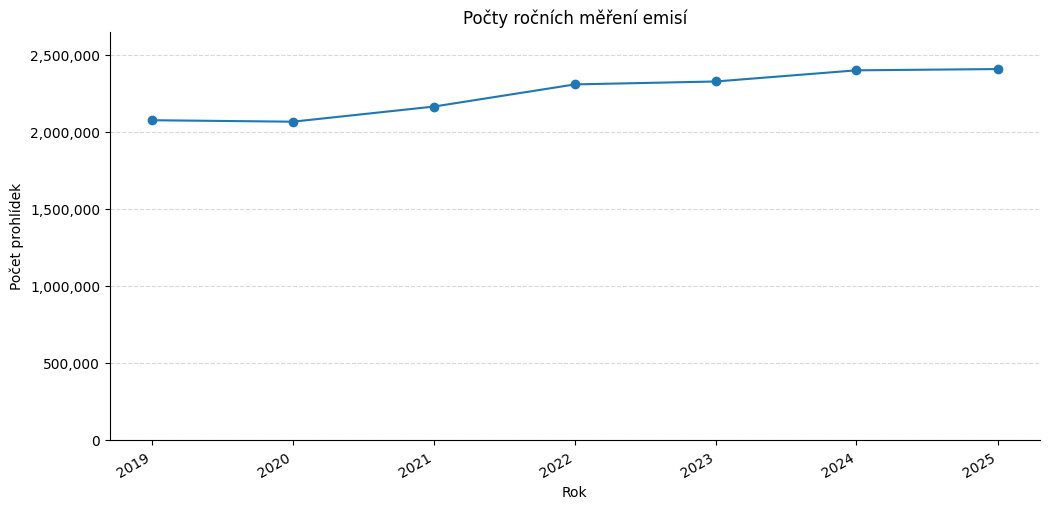

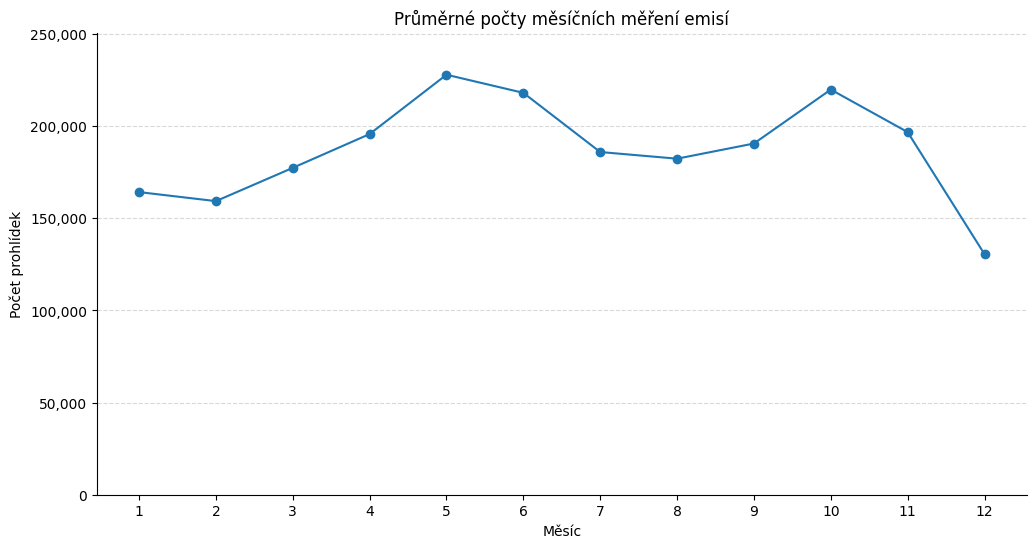

In [26]:
if PRINT:
    time_series_all(df['DatumProhlidky'], 'Počty měsíčních měření emisí', 'Počet prohlídek', '1mo', 'kod/explorace/prohlidky_grafy/prohlidky_mesicne.svg')
    time_series_all(df['DatumProhlidky'], 'Počty ročních měření emisí', 'Počet prohlídek', '1y', 'kod/explorace/prohlidky_grafy/prohlidky_rocne.svg')
    time_series_year(df['DatumProhlidky'], 'Průměrné počty měsíčních měření emisí', 'Počet prohlídek', 'kod/explorace/prohlidky_grafy/prohlidky_v_roce.svg')

## Prohlidka zahajeni, Prohlidka ukonceni

In [27]:
if PRINT:
    print(f'Pocet prohlidek se zapornou delkou: {df.filter(pl.col('Prohlidka_Ukonceni') - pl.col('Prohlidka_Zahajeni') < 0).height}')
    print(f'Pocet prohlidek s nulovou delkou: {df.filter(pl.col('Prohlidka_Ukonceni') - pl.col('Prohlidka_Zahajeni') == 0).height}')
    print(f'Pocet mereni emisi zacinajicich drive, nez zacne prohlidka: {df.filter(pl.col('Emise_Zahajeni') - pl.col('Prohlidka_Zahajeni') < 0).height}')
    print(f'Pocet mereni emisi koncicich pozdeji, nez skonci prohlidka: {df.filter(pl.col('Prohlidka_Ukonceni') - pl.col('Emise_Ukonceni') < 0).height}')

Pocet prohlidek se zapornou delkou: 0
Pocet prohlidek s nulovou delkou: 1435
Pocet mereni emisi zacinajicich drive, nez zacne prohlidka: 3990
Pocet mereni emisi koncicich pozdeji, nez skonci prohlidka: 4


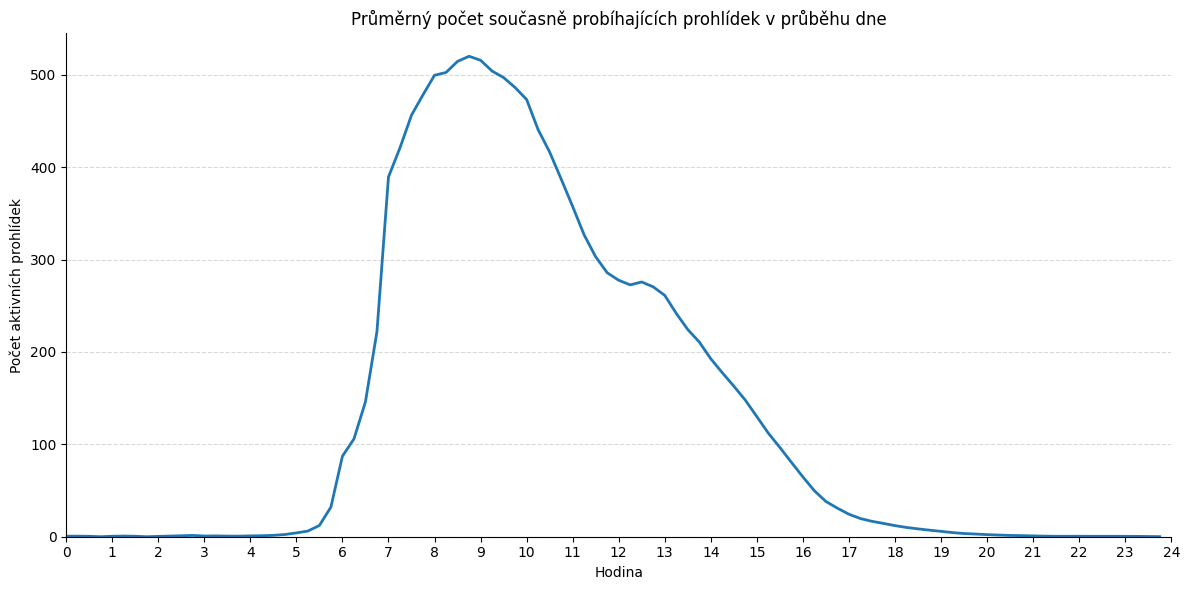

In [28]:
if PRINT:
    active_prohlidky_day_plot(
        df=df,
        start_col='Prohlidka_Zahajeni',
        end_col='Prohlidka_Ukonceni',
        title='Průměrný počet současně probíhajících prohlídek v průběhu dne',
        y_title='Počet aktivních prohlídek',
        interval="15m",
        save_path='kod/explorace/prohlidky_grafy/prohlidky_aktivni_ve_dni.svg'
    )

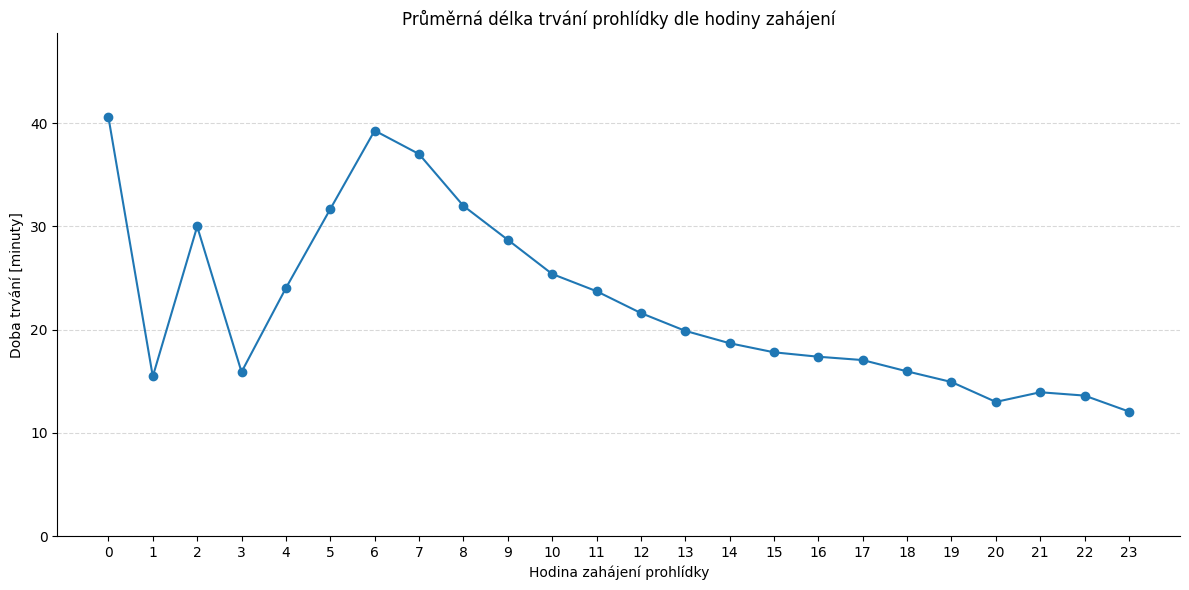

In [29]:
if PRINT:
    # Volání funkce
    duration_prohlidky_plot(
        df=df.filter(pl.col('TechnickaCast_Pritomno') == False),
        start_col='Prohlidka_Zahajeni',
        end_col='Prohlidka_Ukonceni',
        title='Průměrná délka trvání prohlídky dle hodiny zahájení',
        y_title='Doba trvání',
        save_path='kod/explorace/prohlidky_grafy/prohlidky_trvani_podle_zahajeni.svg'
    )

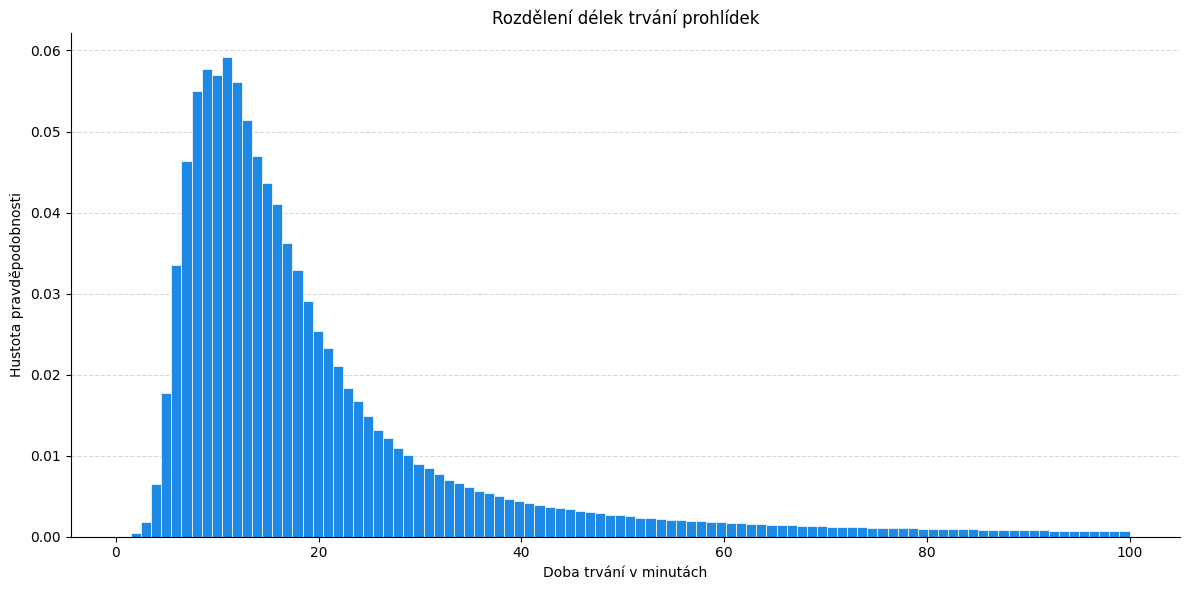

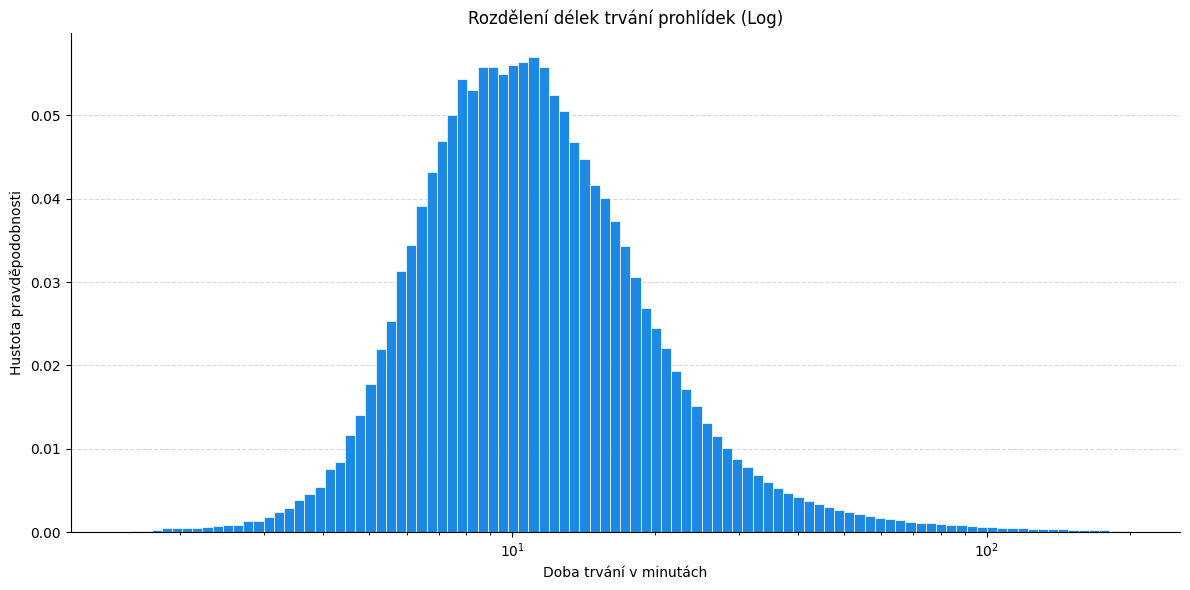

In [30]:
if PRINT:
    # Volání pro lineární měřítko
    duration_density_plot(
        df=df.filter(pl.col('TechnickaCast_Pritomno') == False).filter(pl.col('Prohlidka_Ukonceni') - pl.col('Prohlidka_Zahajeni') < pl.duration(minutes=100)),
        start_col='Prohlidka_Zahajeni',
        end_col='Prohlidka_Ukonceni',
        title='Rozdělení délek trvání prohlídek',
        x_label='Doba trvání v minutách',
        save_path='kod/explorace/prohlidky_grafy/prohlidky_doba_trvani.svg'
    )

    # Volání pro logaritmické měřítko
    duration_density_plot(
        df=df.filter(pl.col('TechnickaCast_Pritomno') == False).filter((pl.col('Prohlidka_Ukonceni') - pl.col('Prohlidka_Zahajeni')).is_between(pl.duration(minutes=1.5), pl.duration(minutes=200))),
        start_col='Prohlidka_Zahajeni',
        end_col='Prohlidka_Ukonceni',
        title='Rozdělení délek trvání prohlídek (Log)',
        x_label='Doba trvání v minutách',
        log_scale=True,
        save_path='kod/explorace/prohlidky_grafy/prohlidky_doba_trvani_log.svg'
    )

## Vozidlo druh

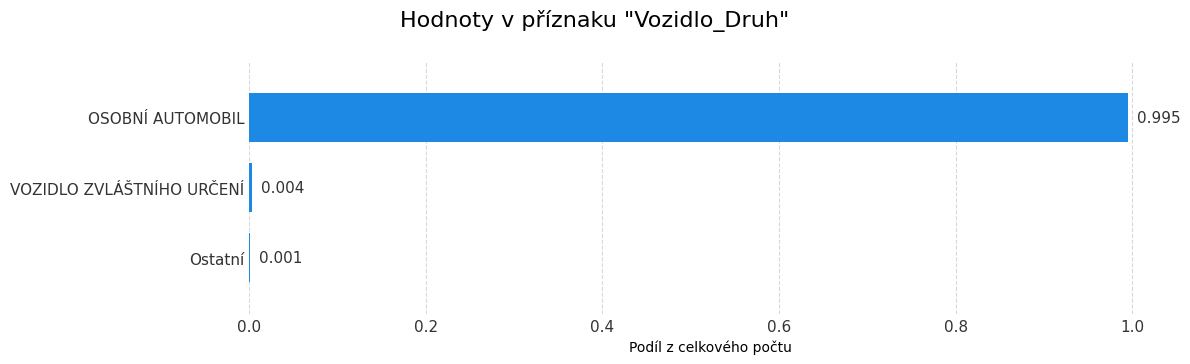

In [31]:
if PRINT:
    vehicle_types = df['Vozidlo_Druh'].value_counts(sort=True)

    horizontal_bar(
        labels=vehicle_types['Vozidlo_Druh'],
        counts=vehicle_types['count'] / df.height,
        title='Hodnoty v příznaku "Vozidlo_Druh"',
        max_bars=3,
        height=4,
        decimals=3,
        save_path='kod/explorace/prohlidky_grafy/prohlidky_vozidlo_druh.svg'
    )

## Vozidlo provedeni

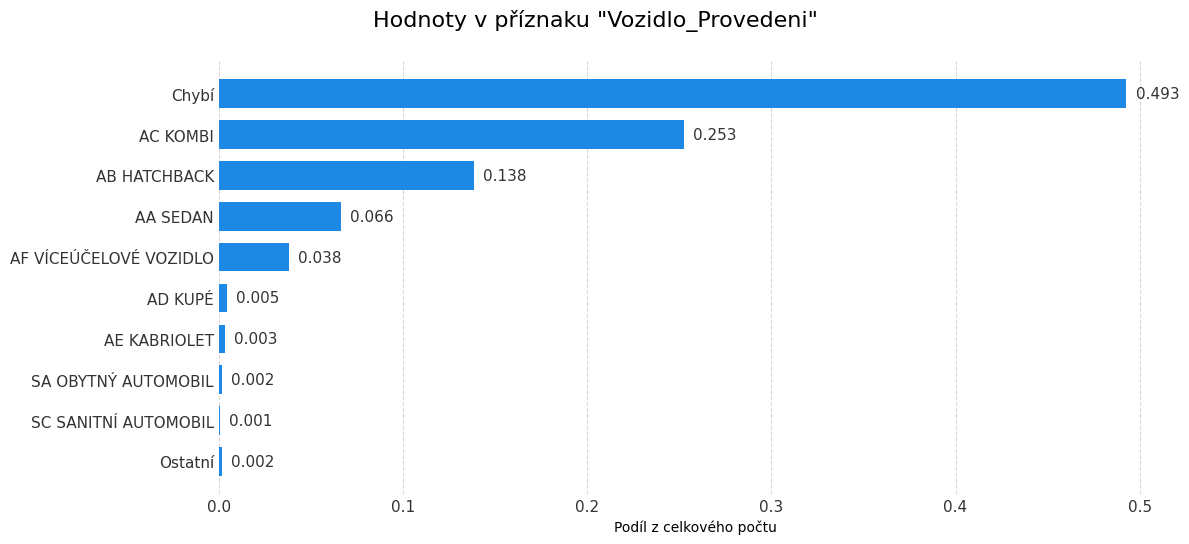

In [32]:
if PRINT:
    vehicle_style = df['Vozidlo_Provedeni'].fill_null('Chybí').value_counts(sort=True)

    horizontal_bar(
        labels=vehicle_style['Vozidlo_Provedeni'],
        counts=vehicle_style['count'] / vehicle_style['count'].sum(),
        title='Hodnoty v příznaku "Vozidlo_Provedeni"',
        decimals=3,
        max_bars=10,
        save_path='kod/explorace/prohlidky_grafy/prohlidky_vozidlo_provedeni.svg'
    )

## Vozidlo znacka

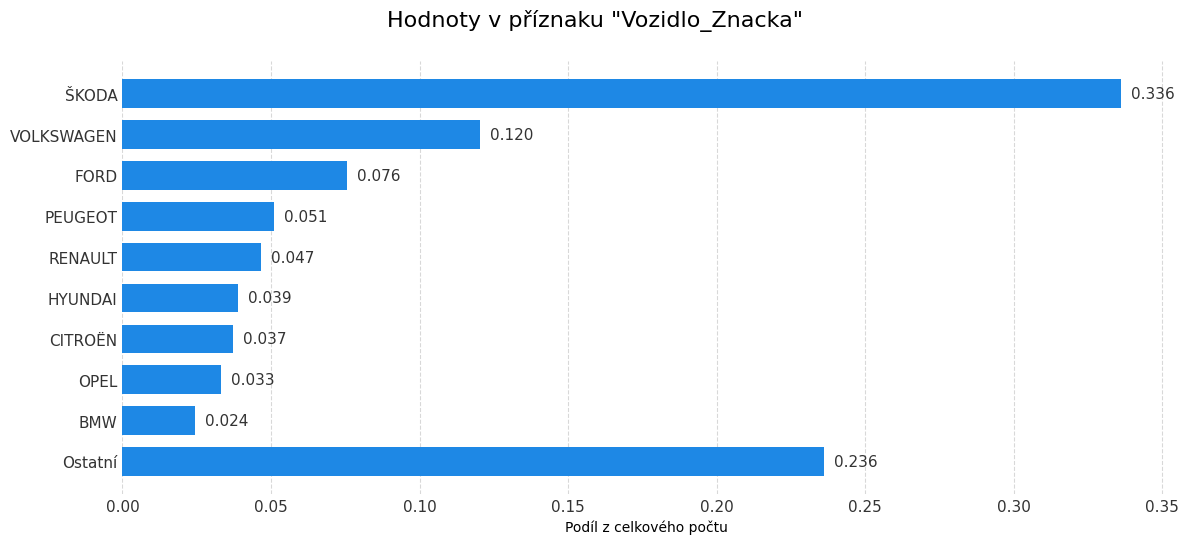

In [33]:
if PRINT:
    vehicle_brand = df['Vozidlo_Znacka'].replace('VW', 'VOLKSWAGEN').fill_null('Chybí').value_counts(sort=True)

    horizontal_bar(
        labels=vehicle_brand['Vozidlo_Znacka'],
        counts=vehicle_brand['count'] / vehicle_style['count'].sum(),
        title='Hodnoty v příznaku "Vozidlo_Znacka"',
        save_path='kod/explorace/prohlidky_grafy/prohlidky_vozidlo_znacka.svg',
        decimals=3,
        max_bars=10
    )

## Vozidlo obchodni oznaceni

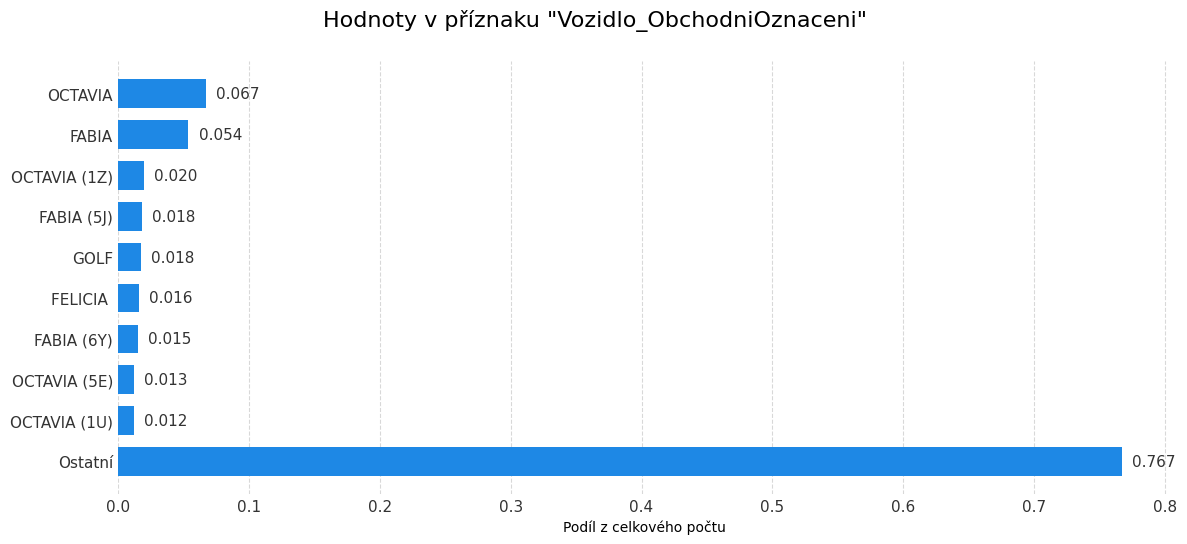

In [34]:
if PRINT:
    vehicle_name = df['Vozidlo_ObchodniOznaceni'].fill_null('Chybí').value_counts(sort=True)

    horizontal_bar(
        labels=vehicle_name['Vozidlo_ObchodniOznaceni'],
        counts=vehicle_name['count'] / vehicle_style['count'].sum(),
        title='Hodnoty v příznaku "Vozidlo_ObchodniOznaceni"',
        save_path='kod/explorace/prohlidky_grafy/prohlidky_vozidlo_obchodni_oznaceni.svg',
        decimals=3,
        max_bars=10
    )

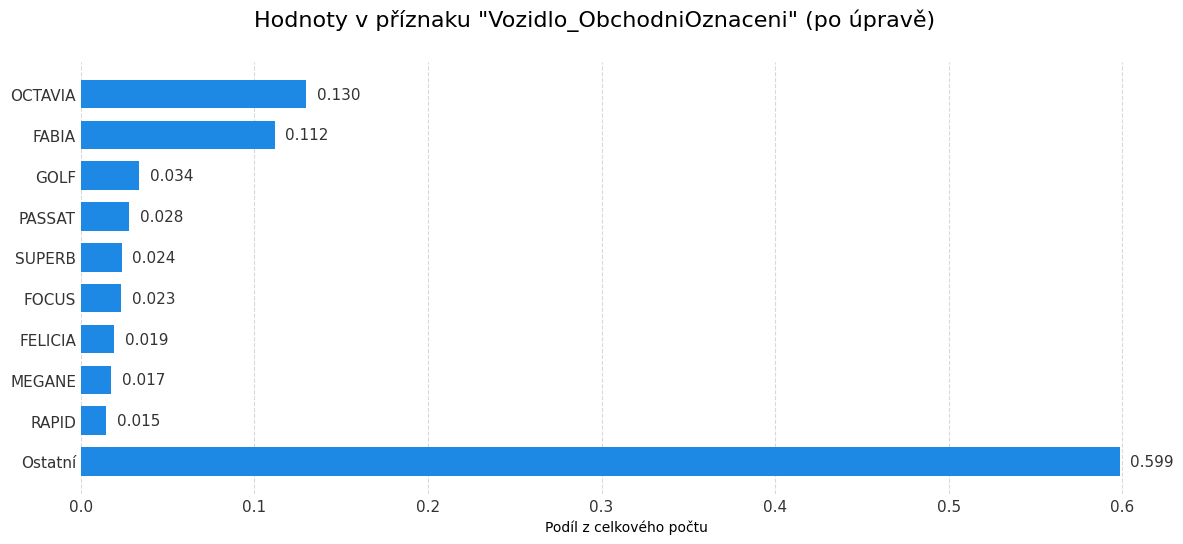

In [35]:
if PRINT:
    # Pouze prvni slovo
    vehicle_name = df['Vozidlo_ObchodniOznaceni'].str.replace(r"\s+.*$", "").value_counts(sort=True)

    horizontal_bar(
        labels=vehicle_name['Vozidlo_ObchodniOznaceni'],
        counts=vehicle_name['count'] / vehicle_style['count'].sum(),
        title='Hodnoty v příznaku "Vozidlo_ObchodniOznaceni" (po úpravě)',
        save_path='kod/explorace/prohlidky_grafy/prohlidky_vozidlo_provedeni_upraveno.svg',
        decimals=3,
        max_bars=10
    )

## Vozidlo typ motoru

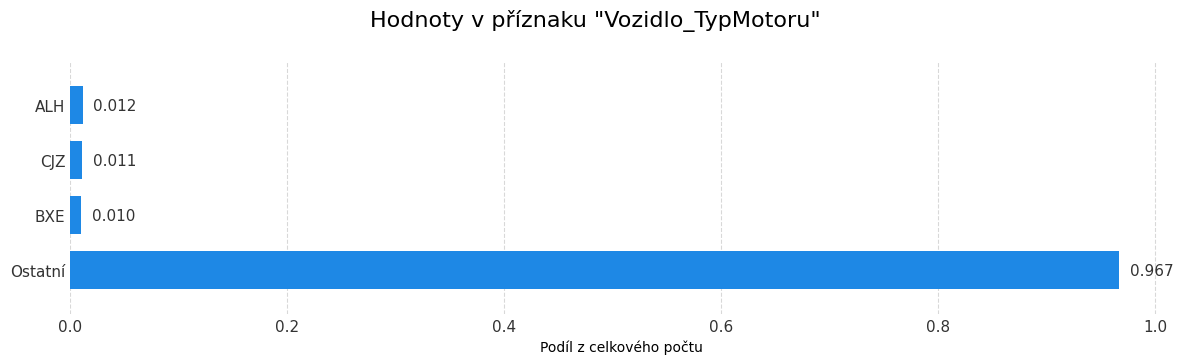

In [36]:
if PRINT:
    engine_type = df['Vozidlo_TypMotoru'].fill_null('Chybí').value_counts(sort=True)

    horizontal_bar(
        labels=engine_type['Vozidlo_TypMotoru'],
        counts=engine_type['count'] / vehicle_style['count'].sum(),
        title='Hodnoty v příznaku "Vozidlo_TypMotoru"',
        save_path='kod/explorace/prohlidky_grafy/prohlidky_vozidlo_typ_motoru.svg',
        decimals=3,
        height=4,
        max_bars=4
    )

## Registrace datum prvni

In [37]:
if PRINT:
    registration_after = df.filter(pl.col('Registrace_DatumPrvni') >= pl.col('Prohlidka_Zahajeni'))
    print(f'Pocet vozidel zaregistrovaych az po prohlidce: {len(registration_after)}')
    registration_future = registration_after.filter(pl.col('Registrace_DatumPrvni') >= datetime(2026, 4, 5))
    print(f'Z toho pocet vozidel zaregistrovaych v budoucnosti: {len(registration_future)}')

Pocet vozidel zaregistrovaych az po prohlidce: 130
Z toho pocet vozidel zaregistrovaych v budoucnosti: 38


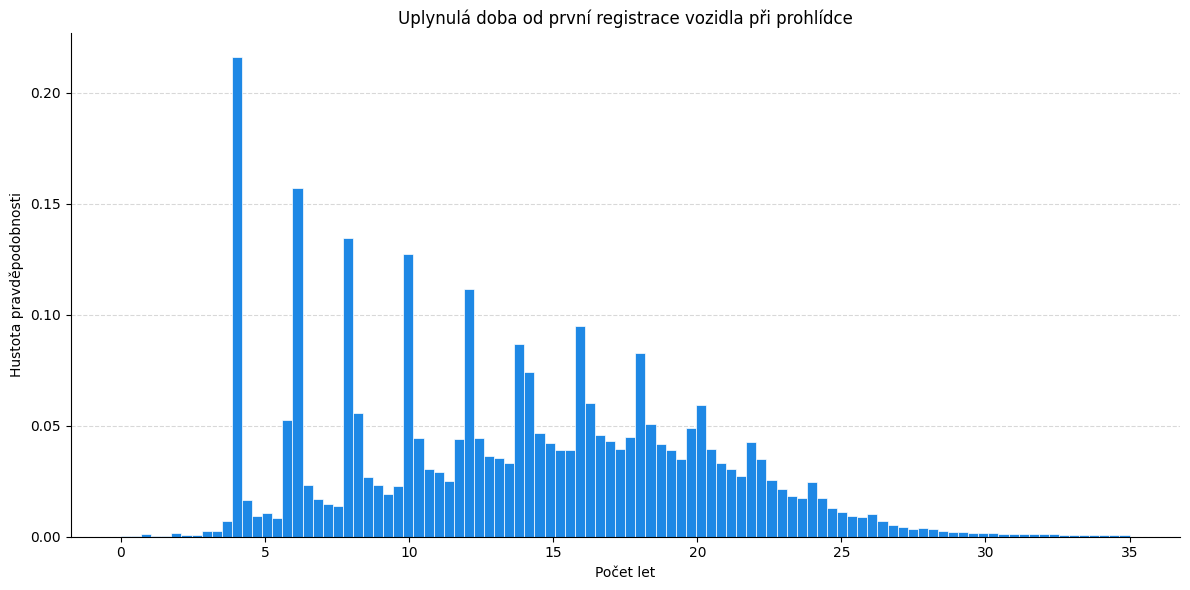

In [38]:
if PRINT:
    duration_density_plot(
        df=df.filter(pl.col('Prohlidka_Zahajeni') - pl.col('Registrace_DatumPrvni') < pl.duration(days=35*365.24)),
        start_col='Registrace_DatumPrvni',
        end_col='Prohlidka_Zahajeni',
        title='Uplynulá doba od první registrace vozidla při prohlídce',
        x_label='Počet let',
        unit='years',
        log_scale=False,
        save_path='kod/explorace/prohlidky_grafy/prohlidky_doba_od_registrace.svg'
    )

## Registrace stat

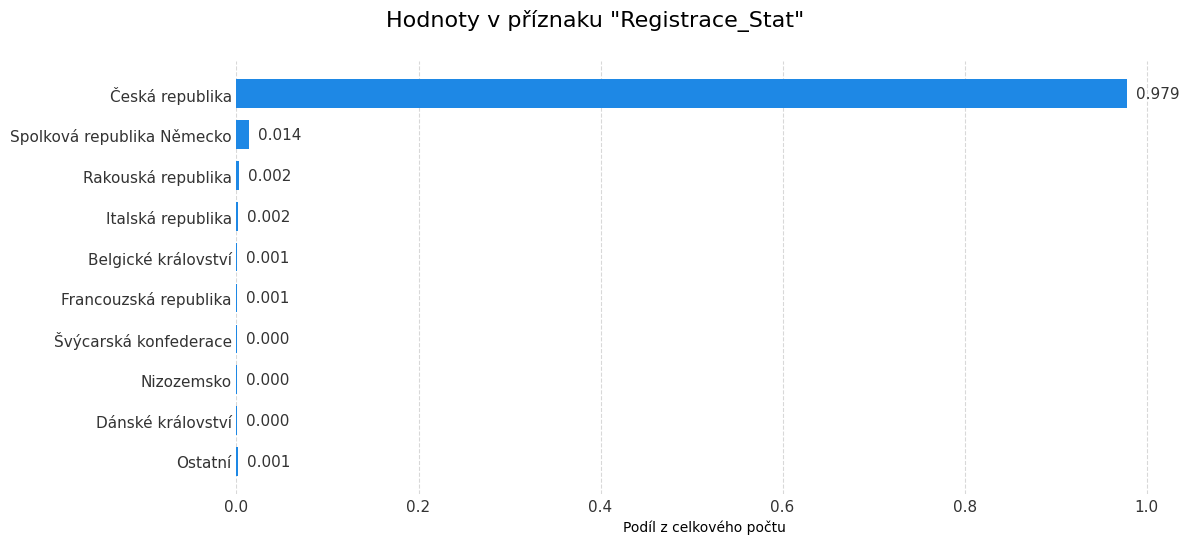

In [39]:
if PRINT:
    registration_country = df['Registrace_Stat'].value_counts(sort=True)

    horizontal_bar(
        labels=registration_country['Registrace_Stat'],
        counts=registration_country['count'] / vehicle_style['count'].sum(),
        title='Hodnoty v příznaku "Registrace_Stat"',
        save_path='kod/explorace/prohlidky_grafy/prohlidky_registrace_stat.svg',
        decimals=3,
        max_bars=10
    )

## Emise zakladni palivo

In [40]:
if PRINT:
    basic_fuel = df['Emise_ZakladniPalivo'].value_counts(sort=True)
    print(f'Pomer vozidel jezdicich na benzin: {basic_fuel.filter(pl.col('Emise_ZakladniPalivo') == 'Benzín').item(row=0, column='count') / df.height * 100:.2f} %.')
    print(f'Pomer vozidel jezdicich na naftu: {basic_fuel.filter(pl.col('Emise_ZakladniPalivo') == 'Nafta').item(row=0, column='count') / df.height * 100:.2f} %.')

Pomer vozidel jezdicich na benzin: 54.33 %.
Pomer vozidel jezdicich na naftu: 45.67 %.


## Technicka, ADR a TSK cast pritomno

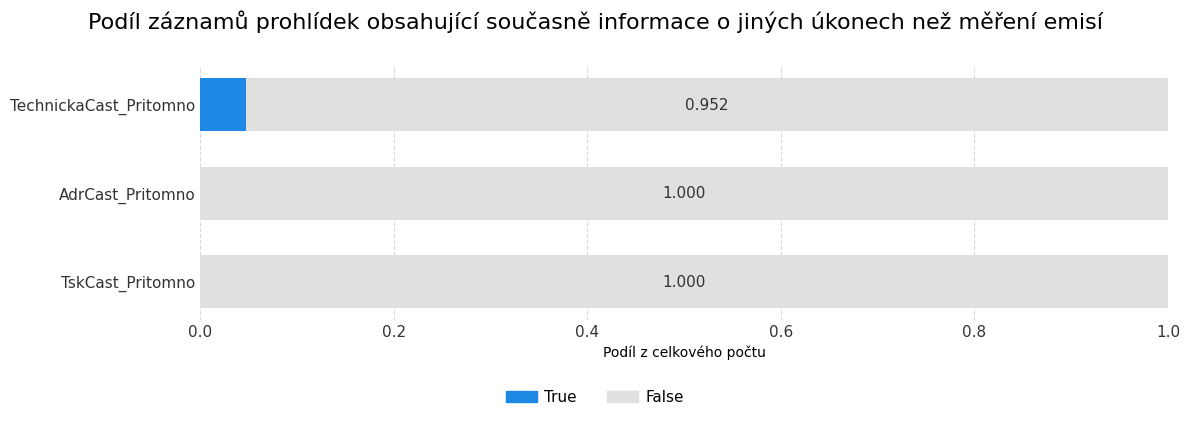

In [41]:
if PRINT:
    cols_to_plot = ['TechnickaCast_Pritomno', 'AdrCast_Pritomno', 'TskCast_Pritomno']

    graph_title = "Podíl záznamů prohlídek obsahující současně informace o jiných úkonech než měření emisí"
    output_file = 'kod/explorace/prohlidky_grafy/prohlidky_pritomne_casti.svg'

    plot_stacked_ratios(df=df, cols=cols_to_plot, title=graph_title, save_path=output_file)

## Vysledek odometr

In [42]:
if PRINT: print(f'Pocet zaznamu s najetymi vice nez 1 000 000 km: {len(df['Vysledek_Odometr'].filter(df['Vysledek_Odometr'] > 1000000))}')

Pocet zaznamu s najetymi vice nez 1 000 000 km: 6630


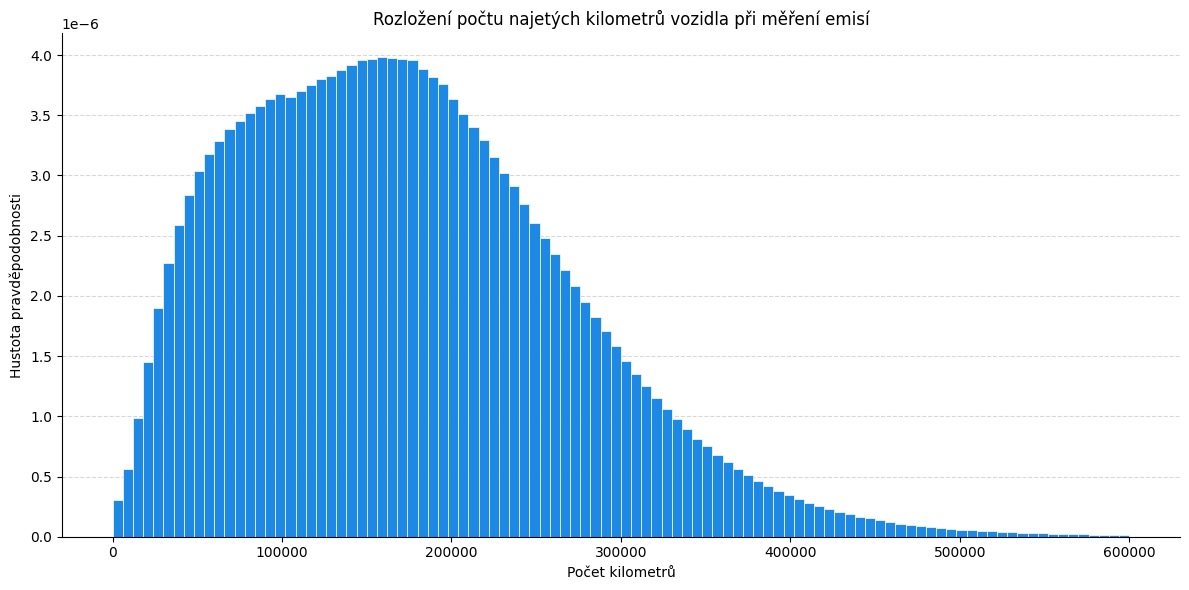

In [43]:
if PRINT:
    distribution_density_plot(
        df=df.filter(pl.col('Vysledek_Odometr') < 600000),
        value_col='Vysledek_Odometr',
        title='Rozložení počtu najetých kilometrů vozidla při měření emisí',
        x_label='Počet kilometrů',
        log_scale=False,
        save_path='kod/explorace/prohlidky_grafy/prohlidky_vysledek_odometr.svg'
    )

## Administrativne opraveno

In [44]:
if PRINT: print(f'Podil administrativne opravenych protokolu: {df['AdministrativneOpraveno'].mean() * 100:.2f} %') # type: ignore

Podil administrativne opravenych protokolu: 0.38 %


# Uprava casovych hodnot do stavu vhodnejsiho pro dalsi analyzu

In [45]:
# Transformace časových údajů pro detekci anomálií
df = df.with_columns([
    # Výpočet délek trvání v minutách (Duration automaticky řeší rozdíly dnů)
    ((pl.col("Prohlidka_Ukonceni") - pl.col("Prohlidka_Zahajeni")).dt.total_seconds() / 60).alias("Doba_Trvani_Prohlidky"),
    ((pl.col("Emise_Ukonceni") - pl.col("Emise_Zahajeni")).dt.total_seconds() / 60).alias("Doba_Trvani_Emisi"),
    
    # Výpočet stáří vozidla v letech
    ((pl.col("DatumProhlidky") - pl.col("Registrace_DatumPrvni")).dt.total_days() / 365.25).alias("Stari_Vozidla_Let"),
    
    # Výpočet radiantů z času (ms od začátku dne / ms v celém dni * 2pi)
    (((pl.col("Prohlidka_Zahajeni") - pl.col("Prohlidka_Zahajeni").dt.date()).dt.total_milliseconds() / 86_400_000).alias('Prohlidka_Cas_zahajeni'))
]).drop([
    # Odstranění původních sloupců a pomocné proměnné
    "DatumProhlidky", 
    "Prohlidka_Zahajeni", 
    "Prohlidka_Ukonceni", 
    "Emise_Zahajeni", 
    "Emise_Ukonceni", 
    "Registrace_DatumPrvni", 
])

df = df.with_columns(pl.col(['Prohlidka_OdpovednaOsoba', 'Prohlidka_Stanice_Cislo', 'Emise_OdpovednaOsoba']).cast(pl.String))

# Ulozeni vysledku

In [46]:
df.write_parquet(r"kod\data\processed\prohlidky_model.parquet")

In [47]:
PRINT = True
if PRINT: describe(df)

CisloProtokolu,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Vozidlo_Druh,Vozidlo_Provedeni,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Registrace_Stat,Emise_OdpovednaOsoba,Emise_ZakladniPalivo,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Vysledek_Odometr,AdministrativneOpraveno,Doba_Trvani_Prohlidky,Doba_Trvani_Emisi,Stari_Vozidla_Let,Prohlidka_Cas_zahajeni
str,str,str,str,str,str,str,str,str,str,str,str,str,str,bool,bool,bool,i32,bool,f64,f64,f64,f64
"""CZ-450227-19-03-0344""","""50195""","""450227""","""Ústecký kraj""","""Varnsdorf""","""Varnsdorf""","""OSOBNÍ AUTOMOBIL""",null,"""VW""","""TOURAN""","""BLS""","""Česká republika""","""27711""","""Nafta""",false,false,false,380740,false,50.766667,6.833333,11.433265,0.3672


(16218646, 23)


,CisloProtokolu,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Vozidlo_Druh,Vozidlo_Provedeni,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,...,Emise_ZakladniPalivo,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Vysledek_Odometr,AdministrativneOpraveno,Doba_Trvani_Prohlidky,Doba_Trvani_Emisi,Stari_Vozidla_Let,Prohlidka_Cas_zahajeni
0,CZ-450227-19-03-0344,50195,450227,Ústecký kraj,Varnsdorf,Varnsdorf,OSOBNÍ AUTOMOBIL,None,VW,TOURAN,...,Nafta,False,False,False,380740,False,50.766667,6.833333,11.433265,0.367200
1,CZ-481003-21-02-0027,42815,481003,Zlínský kraj,Vsetín,Vsetín,OSOBNÍ AUTOMOBIL,AB HATCHBACK,MAZDA,323,...,Benzín,False,False,False,227056,False,12.400000,8.133333,22.242300,0.531640
2,CZ-430216-24-05-0178,65255,430216,Jihočeský kraj,Český Krumlov,Dolní Třebonín,OSOBNÍ AUTOMOBIL,AC KOMBI,DACIA,DUSTER,...,Nafta,False,False,False,87739,False,45.666667,18.500000,12.268309,0.699512
3,CZ-470542-25-05-0218,49389,470542,Zlínský kraj,Otrokovice,Otrokovice,OSOBNÍ AUTOMOBIL,None,MAZDA,6,...,Benzín,False,False,False,234427,False,24.233333,23.083333,15.797399,0.289126
4,CZ-480756-20-04-0223,37311,480756,Moravskoslezský kraj,Ostrava,Ostrava,OSOBNÍ AUTOMOBIL,None,ŠKODA,FABIA COMBI,...,Benzín,False,False,False,185701,False,12.100000,7.900000,19.293634,0.451773
5,CZ-410445-22-02-1108,37065,410445,Hlavní město Praha,Hlavní město Praha,Praha,OSOBNÍ AUTOMOBIL,AD KUPÉ,SMART,FORTWO COUPE,...,Benzín,False,False,False,164433,False,92.766667,12.366667,17.711157,0.373032
6,CZ-460238-24-01-0071,1063,460238,Královéhradecký kraj,Hradec Králové,Chlumec nad Cidlinou,OSOBNÍ AUTOMOBIL,AC KOMBI,VW,PASSAT VARIANT (3BG),...,Nafta,False,False,False,338826,False,65.550000,7.633333,20.287474,0.517923
7,CZ-410627-21-03-0559,66665,410627,Hlavní město Praha,Hlavní město Praha,Praha,OSOBNÍ AUTOMOBIL,AA SEDAN,ŠKODA,OCTAVIA (5E),...,Nafta,False,False,False,50066,False,25.000000,16.416667,4.000000,0.361965
8,CZ-420624-22-04-0342,42353,420624,Středočeský kraj,Mělník,Mělník,OSOBNÍ AUTOMOBIL,AC KOMBI,ŠKODA,SUPERB (3T),...,Nafta,False,False,False,150728,False,73.250000,24.800000,11.583847,0.312280
9,CZ-560501-26-03-0020,41765,560501,Královéhradecký kraj,Náchod,Zábrodí,OSOBNÍ AUTOMOBIL,AC KOMBI,CITROËN,BERLINGO,...,Nafta,False,False,False,119691,False,16.816667,16.216667,9.963039,0.269090


,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-480756-21-03-0244,1 / 16 218 646,0 / 16 218 646,String
1,Prohlidka_OdpovednaOsoba,35165,55 725 / 16 218 646,0 / 16 218 646,String
2,Prohlidka_Stanice_Cislo,540514,254 043 / 16 218 646,0 / 16 218 646,String
3,Prohlidka_Stanice_Kraj,Středočeský kraj,2 344 213 / 16 218 646,0 / 16 218 646,String
4,Prohlidka_Stanice_ORP,Hlavní město Praha,1 682 833 / 16 218 646,0 / 16 218 646,String
5,Prohlidka_Stanice_Obec,Praha,1 682 833 / 16 218 646,0 / 16 218 646,String
6,Vozidlo_Druh,OSOBNÍ AUTOMOBIL,16 136 468 / 16 218 646,0 / 16 218 646,String
7,Vozidlo_Provedeni,AC KOMBI,4 095 426 / 16 218 646,7 992 325 / 16 218 646,String
8,Vozidlo_Znacka,ŠKODA,5 451 446 / 16 218 646,0 / 16 218 646,String
9,Vozidlo_ObchodniOznaceni,OCTAVIA,1 087 227 / 16 218 646,0 / 16 218 646,String
